This notebook demonstrates how to simulate data from an Inverse Gamma model. 
We first plot v vs x, where v is inverse-gamma and x is normal with variance v.
We next try to develop a time series of log returns y which produces q-variance for all periods T.
The resulting model comes close to matching q-variance when averaged over a million points.
However the model is highly unstable and requires more than three parameters.
For simplicity we consider the case where there is no horizontal offset, which requires an extra parameter.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import binned_statistic

# parameters
sig = 0.259
shape = 1.5
rate = sig**2
n = int(1e6)

# simulation of v and x
v = 1 / np.random.gamma(shape, 1/rate, n)
x = np.random.normal(0, np.sqrt(v), n)

xq = np.arange(-1, 1, 0.01)
vq = sig**2 + xq**2 / 2

df = pd.DataFrame({'x': x, 'v': v})

# group the data into bins to calculate the mean variance curve
bins = np.arange(-1, 1.05, 0.05)
df['bin_mid'] = pd.cut(df['x'], bins).apply(lambda x: x.mid).astype(float)
binned_summary = df.groupby('bin_mid', observed=True)['v'].mean().reset_index()


Plot the results with no time series

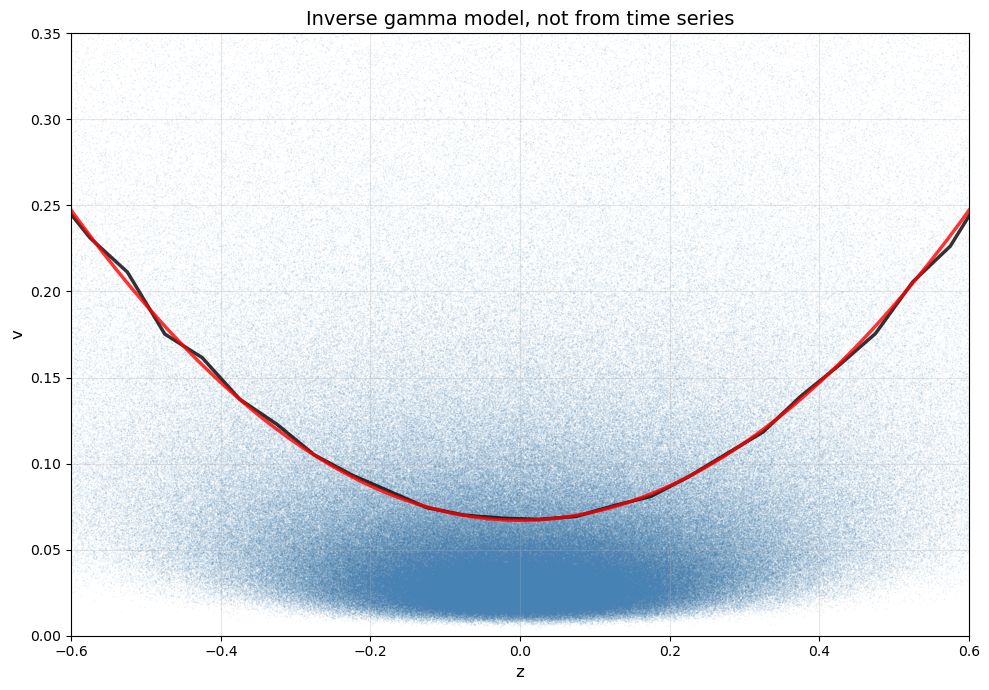

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(df['x'], df['v'], color='steelblue', alpha=0.1, s=1, edgecolors='none')
ax.plot(binned_summary['bin_mid'], binned_summary['v'], color='black', linewidth=2.5, alpha=0.8)
ax.plot(xq, vq, color='red', linewidth=2.5, alpha=0.8)

ax.set_xlim(-0.6, 0.6)
ax.set_ylim(0, 0.35)
ax.set_xlabel('z', fontsize=12)
ax.set_ylabel('v', fontsize=12)

#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

plt.title('Inverse gamma model, not from time series', fontsize=14)
plt.tight_layout()

plt.show()

Now try to match by using exponentially distributed intervals.
Variance in each interval is drawn from an inverse-gamma distribution.
The model gives an approximate fit to q-variance.

In [6]:

def get_time_series(M=1e5, avg_length=500, sigma_0_sq=0.01):
    # Interval generation
    raw_T = np.random.exponential(avg_length, size=int(M/avg_length * 2))
    T_j = np.maximum(np.round(raw_T).astype(int), 1)
    
    # Exact fit to M
    cum_T = np.cumsum(T_j)
    idx = np.searchsorted(cum_T, M)
    T_j = T_j[:idx+1]
    T_j[-1] = M - (cum_T[idx-1] if idx > 0 else 0)

    # Variance sampling (Inv-Gamma)
    v_j = 1.0 / np.random.gamma(1.5, 1.0/sigma_0_sq, size=len(T_j))
    
    # Expand variance to time series and sample returns
    v_i = np.repeat(v_j, T_j)
    r_i = np.random.normal(0, np.sqrt(v_i))
    price_path = np.cumsum(r_i)

    return r_i, v_i, price_path

# Parameters
M = n             # Total days e.g. 1e6
avg_length = 2000     # Average days per variance regime
sigma_0 = sig   # boost to give better fit
sigma_0_sq = sigma_0**2/252  # Rate parameter for Inverse-Gamma

log_returns, intervals, variances = get_time_series(M, avg_length, sigma_0_sq)

rows = []
scale = np.sqrt(252)

print("Computing Q-Variance curve for T = 1 to 26 weeks...")
HORIZONS = 5*(np.arange(26)+1)   # does 1 to 26 weeks, can also do [5, 10, 20, 40, 80, 160]
for T in HORIZONS:
    i = 0
    while i + T <= len(log_returns):
        window = log_returns[i:i+T]     # T points
        if len(window) < T * 0.8:
            break

        x = window.sum()   # total price change over the period
        sigma = np.std(window, ddof=0) * scale      # ddof=0 means divisor is N, not N-1
        varcur = sigma**2
        z_raw = x / np.sqrt(T / 252.0)

        # REJECT BAD WINDOWS
        if not (np.isfinite(sigma) and sigma > 0 and np.isfinite(z_raw)):
            i += T
            continue

        rows.append({          # append row of data for this period
            "T": T,
            "z_raw": float(z_raw),
            "var": float(varcur)
        })
        i += T

df = pd.DataFrame(rows)

# CLEAN BEFORE DE-MEANING 
df = df[np.isfinite(df['z_raw']) & np.isfinite(df['var']) & (df['var'] > 0)]

# NOW de-mean safely, this step groups by T, and subtracts the group mean 
df["z"] = df.groupby(["T"])["z_raw"].transform(lambda g: g - g.mean())

df = df.drop(columns="z_raw")
df = df.dropna().reset_index(drop=True)  # Final clean, can save as e.g. parquet file

print(f"Generated {len(df["z"]):,} data points")



Computing Q-Variance curve for T = 1 to 26 weeks...
Generated 770,875 data points


The model is unstable, so the quality of fit varies.


Q-Variance Fit Results:
  R²   = 0.9228


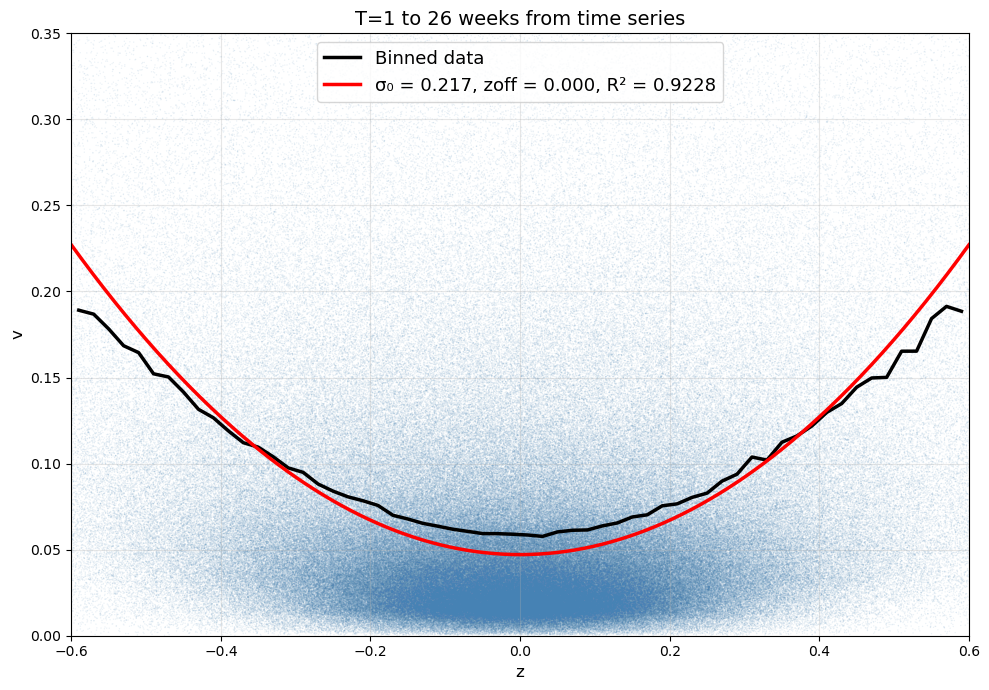

In [5]:
def q_variance_model(z, sigma_0_sq, zoff):
    return sigma_0_sq + (z - zoff)**2 / 2

# Binning
zmax = 0.6
Z_BINS = np.linspace(-zmax, zmax, 61)
bin_means, bin_edges, _ = binned_statistic(df["z"], df["var"], statistic='mean', bins=Z_BINS)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
valid = ~np.isnan(bin_means)

# Fit
popt, pcov = curve_fit(q_variance_model, bin_centers[valid], bin_means[valid],
                       p0=[0.26**2, 0.0], bounds=([0.01, -0.1], [0.5, 0.1]))
sigma_0_sq_fit, zoff_fit = popt
#sigma_0_sq_fit = sigma_0_sq*252  # do not fit, use theoretical curve but annualized
zoff_fit = 0

#perr = np.sqrt(np.diag(pcov))

# R²
#predicted = q_variance_model(bin_centers[valid], *popt)
predicted = q_variance_model(bin_centers[valid], sigma_0_sq_fit, 0)
ss_res = np.sum((bin_means[valid] - predicted)**2)
ss_tot = np.sum((bin_means[valid] - np.mean(bin_means[valid]))**2)
r_squared = 1 - ss_res / ss_tot

print(f"\nQ-Variance Fit Results:")
#print(f"  σ₀   = {sigma_0_sq_fit:.4f} ± {perr[0]:.4f}")
#print(f"  zoff = {zoff_fit:.4f} ± {perr[1]:.4f}")
print(f"  R²   = {r_squared:.4f}")

plt.figure(figsize=(10, 7))

# Scatter plot
plt.scatter(df["z"], df["var"], c='steelblue', alpha=0.1, s=1, edgecolor='none')

# Binned data
plt.plot(bin_centers[valid], bin_means[valid], 'k-', lw=2.5, label='Binned data')

# Q-Variance fit, note results will vary because model is unstable
z_fine = np.linspace(-zmax, zmax, 500)
sigma_0_fit = np.sqrt(sigma_0_sq_fit)
plt.plot(z_fine, q_variance_model(z_fine, sigma_0_sq_fit, 0),
         color='red', lw=2.5,
         label=f'σ₀ = {sigma_0_fit:.3f}, zoff = {zoff_fit:.3f}, R² = {r_squared:.4f}')

plt.xlabel('z', fontsize=12)
plt.ylabel('v', fontsize=12)
plt.title('T=1 to 26 weeks from time series', fontsize=14)
plt.xlim(-0.6, 0.6)
plt.ylim(0, 0.35)
plt.grid(alpha=0.3)
plt.legend(fontsize=13, loc='upper center')
plt.tight_layout()

# Save for publication
# plt.savefig("Q_Variance_Parabola.png", dpi=300, bbox_inches='tight')
# plt.savefig("Q_Variance_Parabola.pdf", bbox_inches='tight')
plt.show()
